# 📊 EDA: A Study on Pocket Money Management among Students
**Dataset:** Google Form Responses — 107 respondents, 29 features  
**Tools:** Pandas · NumPy · Seaborn · Matplotlib

## 1️⃣  Import Libraries & Load Dataset

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# ── Create output folder ────────────────────────────────────────
OUTPUT_DIR = 'output_eda'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'✅  Output folder ready: {os.path.abspath(OUTPUT_DIR)}')

# ── Normal / light theme ────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f7f7f7',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlepad':    12,
    'figure.titlesize': 16,
    'figure.titleweight': 'bold',
})

PALETTE = sns.color_palette('tab10')

FILE = 'A Study on Pocket Money Management among Students (Responses).xlsx'
df_raw = pd.read_excel(FILE)
print(f'✅  Loaded  →  {df_raw.shape[0]} rows  ×  {df_raw.shape[1]} columns')
df_raw.head(3)

✅  Output folder ready: D:\lohith_prj\output_eda


✅  Loaded  →  107 rows  ×  29 columns


,Timestamp,Name,What is your current age group?,What is your gender?,What type of family setup do you currently live in?,What is your current educational level/Course of Study?,What is your current stream of study?,How frequently do you receive pocket money?,"On average, how much pocket money do you receive per month (in ₹)?",What are your major spending areas? (Select all that apply),...,"Rate your agreement with the following statements regarding influencing factors (1=Strongly Disagree, 5=Strongly Agree): [Advertisements affect my spending habits.]",Do you feel pressured to spend money to maintain a certain lifestyle or fit in with your peers?,How often do you discuss money management or financial topics with your parents/guardians?,How would you rate your current level of financial literacy/knowledge?,Please rate the following sources of financial knowledge/literacy. (5 being the most influential): [Parents/Family],Please rate the following sources of financial knowledge/literacy. (5 being the most influential): [Friends/Peers],Please rate the following sources of financial knowledge/literacy. (5 being the most influential): [School/College Curriculum],Please rate the following sources of financial knowledge/literacy. (5 being the most influential): [Social Media/Internet Resources],Please rate the following sources of financial knowledge/literacy. (5 being the most influential): [Self-Learning/Experience],Which of the following tools or methods do you use to manage and track your pocket money? (Select all that apply)
0,2026-03-11 08:33:38.698,LOHITH R,21–23,Male,Nuclear Family (parents and children),Undergraduate (UG),Commerce,Monthly,"₹1,000 - ₹3,000","Food & Snacks/Beverages (Eating out/Cafes), En...",...,3 (Neutral),Sometimes,3,5,2nd,5th (Least Influential),4th,3rd,1st (Most Influential),Mobile Banking Apps
1,2026-03-11 08:37:58.321,rajesh d,21–23,Male,Nuclear Family (parents and children),Undergraduate (UG),Science,Monthly,"₹3,001 - ₹5,000","Food & Snacks/Beverages (Eating out/Cafes), En...",...,4 (Agree),"No, not at all",3,5,4th,5th (Least Influential),3rd,2nd,1st (Most Influential),Mobile Banking Apps
2,2026-03-11 08:46:18.222,Logesh,21–23,Male,Nuclear Family (parents and children),Professional Course,Commerce,Occasionally/ Only when I ask for it,"Below ₹1,000","Shopping (Clothes, Accessories, Gadgets), Tran...",...,3 (Neutral),"No, not at all",1,2,1st (Most Influential),3rd,5th (Least Influential),4th,2nd,Mobile Banking Apps


## 2️⃣  Data Cleaning & Preprocessing

In [2]:
df = df_raw.copy()

df.columns = [
    'Timestamp', 'Name', 'Age_Group', 'Gender', 'Family_Type',
    'Education_Level', 'Stream', 'Pocket_Money_Frequency',
    'Pocket_Money_Amount', 'Spending_Areas', 'Top_Spend_Category',
    'Expense_Tracking_Freq', 'Run_Out_Freq', 'Saves_Money',
    'Savings_Percent', 'Savings_Storage', 'Savings_Motivation',
    'Influence_Discounts', 'Influence_SocialMedia', 'Influence_Ads',
    'Peer_Pressure', 'Parent_Discussion_Freq', 'Financial_Literacy_Rating',
    'Source_Parents', 'Source_Peers', 'Source_School',
    'Source_SocialMedia', 'Source_SelfLearning', 'Tracking_Tools'
]

# Extract numeric from Likert columns
for col in ['Influence_Discounts', 'Influence_SocialMedia', 'Influence_Ads']:
    df[col] = df[col].astype(str).str.extract(r'(\d)').astype(float)

# Map rank columns (1=most influential)
rank_map = {'1st (Most Influential)':1,'2nd':2,'3rd':3,'4th':4,'5th (Least Influential)':5}
rank_cols = ['Source_Parents','Source_Peers','Source_School','Source_SocialMedia','Source_SelfLearning']
for col in rank_cols:
    df[col] = df[col].map(rank_map)

amount_order = [
    'Less than \u20b9500','\u20b9500 - \u20b9999',
    '\u20b91,000 - \u20b93,000','\u20b93,001 - \u20b95,000',
    '\u20b95,001 - \u20b910,000','More than \u20b910,000'
]

print('Missing values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'None')
print(f'\nDuplicates: {df.duplicated().sum()}')
print(f'Final shape: {df.shape}')

Missing values:
Source_Parents         71
Source_Peers           71
Source_School          71
Source_SocialMedia     71
Source_SelfLearning    71
dtype: int64

Duplicates: 0
Final shape: (107, 29)


## 3️⃣  Descriptive Statistics

In [3]:
num_cols = ['Financial_Literacy_Rating', 'Parent_Discussion_Freq',
            'Influence_Discounts', 'Influence_SocialMedia', 'Influence_Ads']
print('=== Numerical Summary ===')
display(df[num_cols].describe().round(2))

cat_cols = ['Age_Group', 'Gender', 'Family_Type', 'Education_Level', 'Stream',
            'Pocket_Money_Frequency', 'Pocket_Money_Amount', 'Saves_Money',
            'Expense_Tracking_Freq', 'Run_Out_Freq', 'Peer_Pressure']
print('\n=== Categorical Value Counts ===')
for col in cat_cols:
    print(f'\n── {col}')
    print(df[col].value_counts().to_string())

=== Numerical Summary ===


,Financial_Literacy_Rating,Parent_Discussion_Freq,Influence_Discounts,Influence_SocialMedia,Influence_Ads
count,107.00,107.00,107.00,107.00,107.00
mean,3.39,3.17,3.06,2.63,2.64
std,1.01,1.22,1.30,1.20,1.22
min,1.00,1.00,1.00,1.00,1.00
25%,3.00,2.00,2.00,2.00,2.00
50%,4.00,3.00,3.00,2.00,3.00
75%,4.00,4.00,4.00,4.00,3.00
max,5.00,5.00,5.00,5.00,5.00



=== Categorical Value Counts ===

── Age_Group
Age_Group
18–20       72
21–23       29
Below 18     4
Above 23     2

── Gender
Gender
Male                 54
Female               52
Prefer not to say     1

── Family_Type
Family_Type
Nuclear Family (parents and children)                                      77
Joint / Extended Family (living with grandparents, uncles, aunts, etc.)    28
Parents and grandma                                                         1
Mom , me , and sister                                                       1

── Education_Level
Education_Level
Undergraduate (UG)              92
High School / Pre-University     7
Postgraduate (PG)                4
Professional Course              3
Other                            1

── Stream
Stream
Commerce                     67
Science                      23
Law                           6
Arts                          5
All subjects                  1
Engineering                   1
Medical                       1

## 4️⃣  Demographics

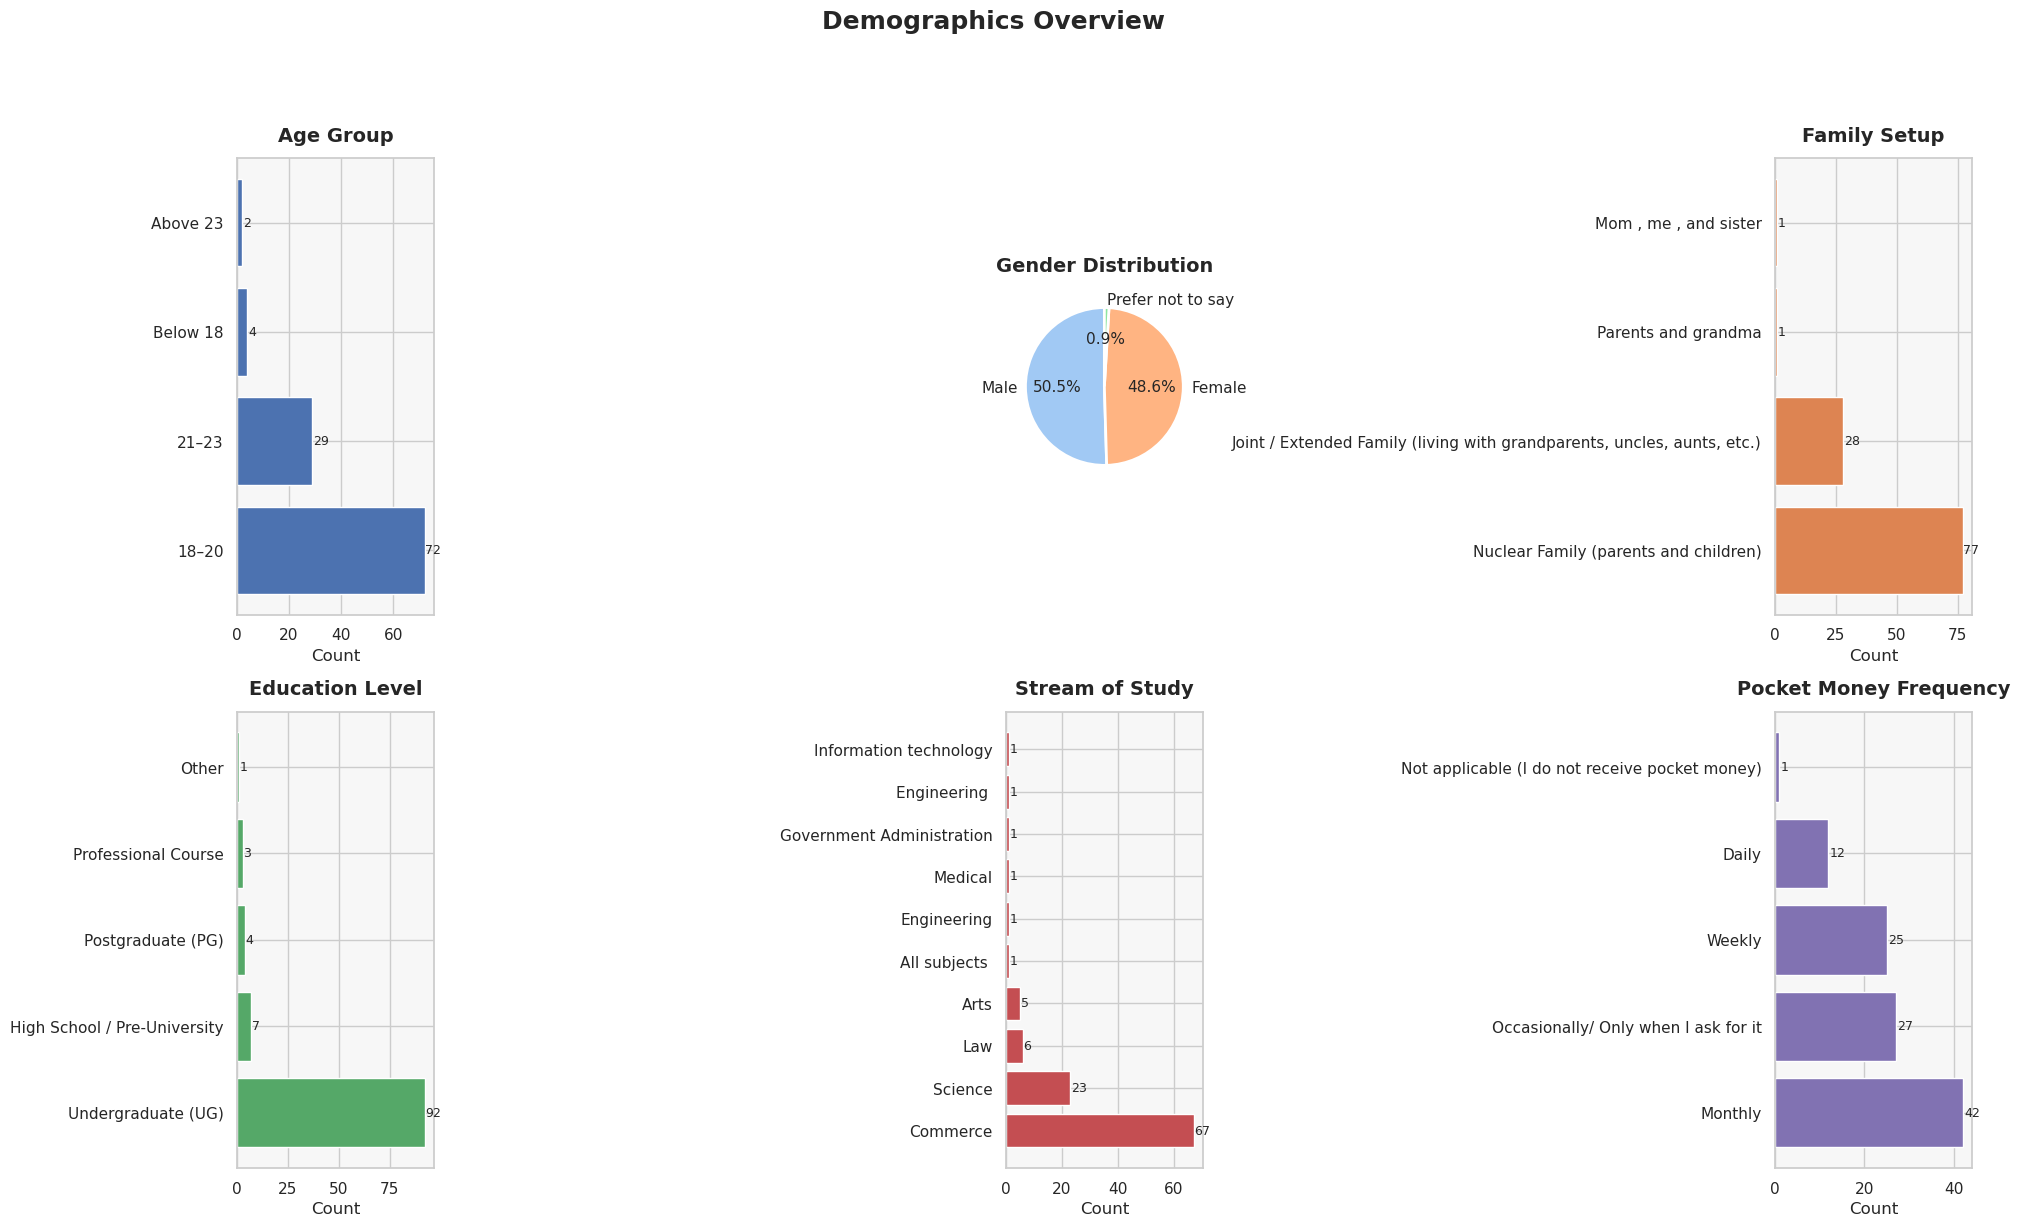

✅  Saved: 01_demographics.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Demographics Overview', fontsize=18, fontweight='bold', y=1.02)

def hbar(ax, col, title, color):
    vc = df[col].value_counts()
    bars = ax.barh(vc.index, vc.values, color=color, edgecolor='white')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Count')
    for b in bars:
        ax.text(b.get_width() + 0.3, b.get_y() + b.get_height()/2,
                str(int(b.get_width())), va='center', fontsize=9)

hbar(axes[0,0], 'Age_Group',               'Age Group',              '#4C72B0')

gc = df['Gender'].value_counts()
axes[0,1].pie(gc.values, labels=gc.index, autopct='%1.1f%%',
              colors=sns.color_palette('pastel'), startangle=90,
              wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0,1].set_title('Gender Distribution', fontsize=14, fontweight='bold', pad=12)

hbar(axes[0,2], 'Family_Type',             'Family Setup',           '#DD8452')
hbar(axes[1,0], 'Education_Level',         'Education Level',        '#55A868')
hbar(axes[1,1], 'Stream',                  'Stream of Study',        '#C44E52')
hbar(axes[1,2], 'Pocket_Money_Frequency',  'Pocket Money Frequency', '#8172B2')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(OUTPUT_DIR, '01_demographics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅  Saved: 01_demographics.png')

## 5️⃣  Pocket Money Amount Distribution

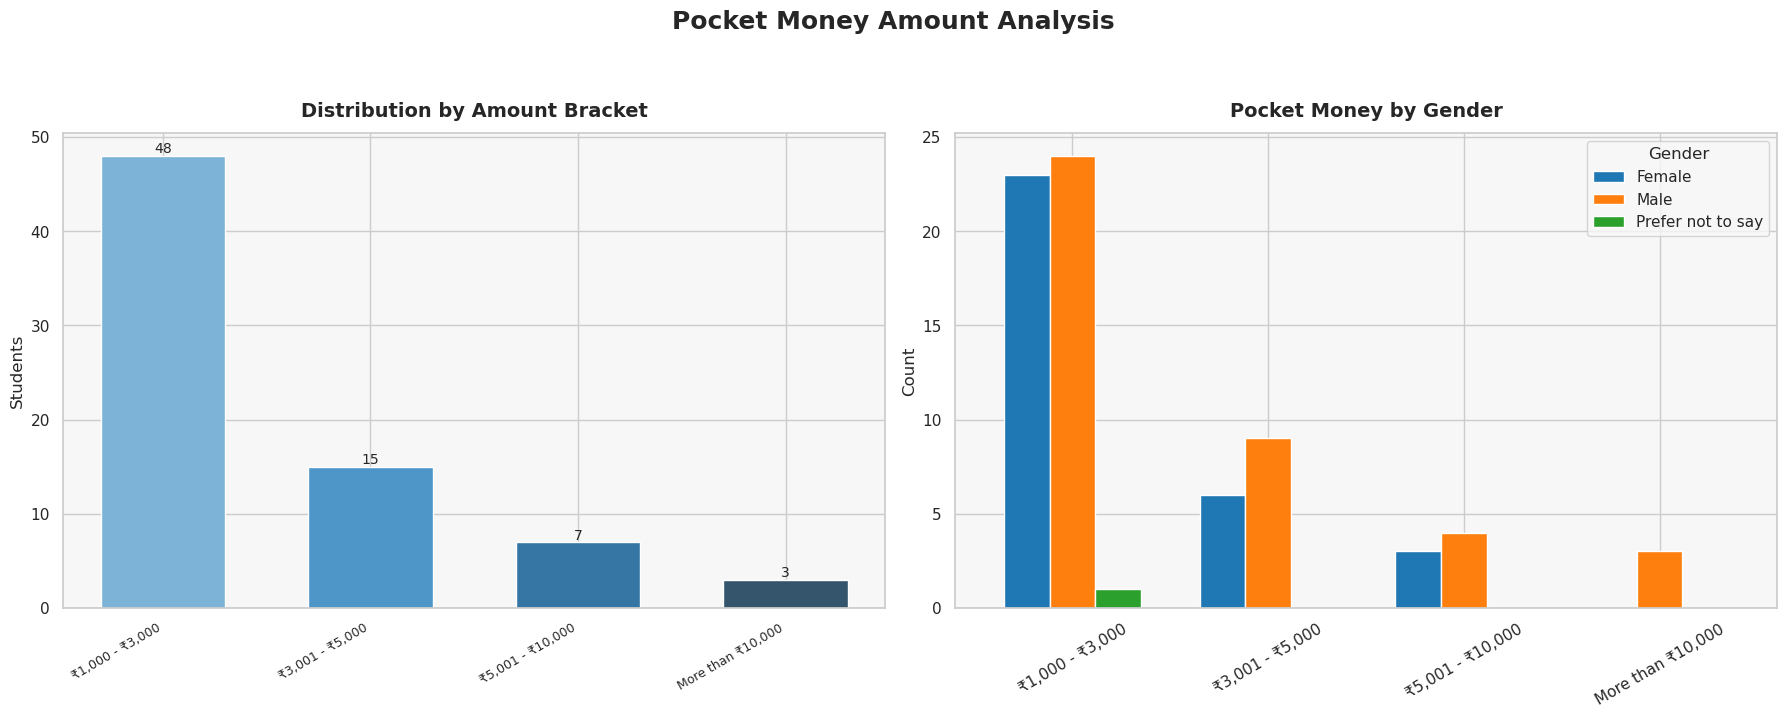

✅  Saved: 02_pocket_money_amount.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Pocket Money Amount Analysis', fontsize=18, fontweight='bold', y=1.02)

amt = df['Pocket_Money_Amount'].value_counts().reindex(
    [a for a in amount_order if a in df['Pocket_Money_Amount'].unique()])
bars = axes[0].bar(range(len(amt)), amt.values,
                   color=sns.color_palette('Blues_d', len(amt)),
                   edgecolor='white', width=0.6)
axes[0].set_xticks(range(len(amt)))
axes[0].set_xticklabels(amt.index, rotation=30, ha='right', fontsize=9)
axes[0].set_title('Distribution by Amount Bracket', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Students')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(int(bar.get_height())), ha='center', fontsize=10)

cross = pd.crosstab(df['Pocket_Money_Amount'], df['Gender'])
cross = cross.reindex([a for a in amount_order if a in cross.index])
cross.plot(kind='bar', ax=axes[1],
           color=sns.color_palette('tab10', cross.shape[1]),
           edgecolor='white', width=0.7)
axes[1].set_title('Pocket Money by Gender', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Gender')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(OUTPUT_DIR, '02_pocket_money_amount.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅  Saved: 02_pocket_money_amount.png')

## 6️⃣  Spending Behaviour

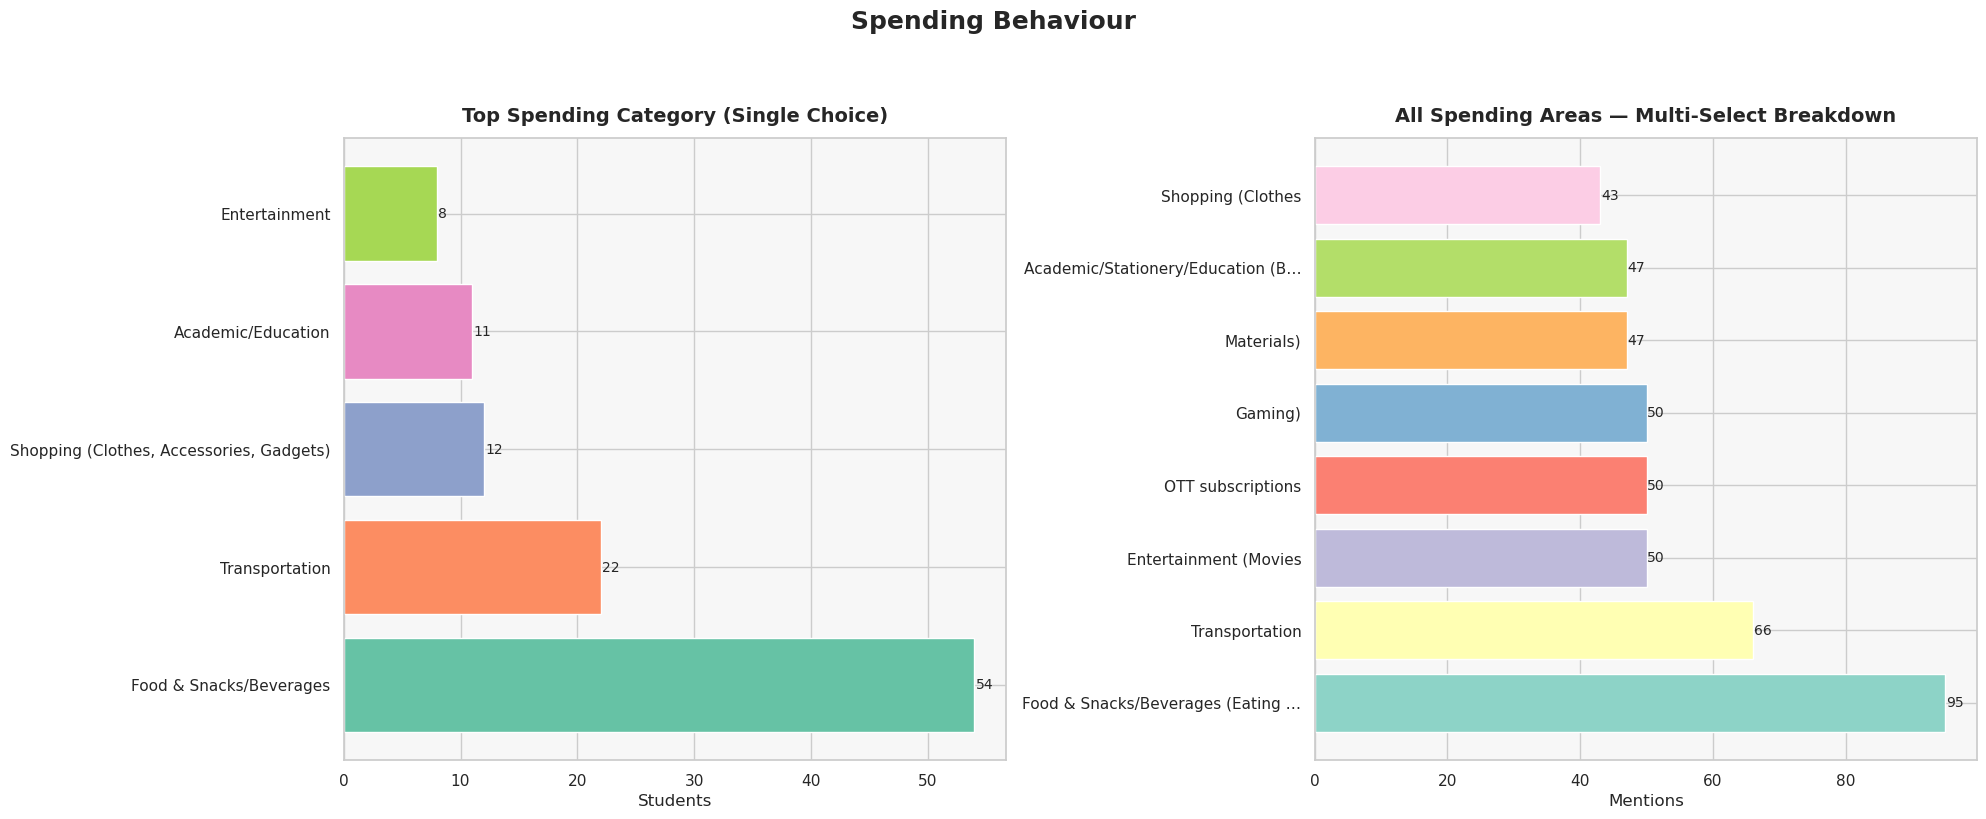

✅  Saved: 03_spending_behaviour.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Spending Behaviour', fontsize=18, fontweight='bold', y=1.02)

# Top spending category
tsc = df['Top_Spend_Category'].value_counts()
axes[0].barh(tsc.index, tsc.values,
              color=sns.color_palette('Set2', len(tsc)), edgecolor='white')
axes[0].set_title('Top Spending Category (Single Choice)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Students')
for i, v in enumerate(tsc.values):
    axes[0].text(v + 0.1, i, str(v), va='center', fontsize=10)

# All spending areas (multi-select exploded)
spend_flat = [item.strip()
              for sublist in df['Spending_Areas'].dropna().str.split(', ')
              for item in sublist]
sc = pd.Series(spend_flat).value_counts().head(8)
short = [l[:32] + '…' if len(l) > 32 else l for l in sc.index]
axes[1].barh(short, sc.values,
              color=sns.color_palette('Set3', len(sc)), edgecolor='white')
axes[1].set_title('All Spending Areas — Multi-Select Breakdown', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Mentions')
for i, v in enumerate(sc.values):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(OUTPUT_DIR, '03_spending_behaviour.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅  Saved: 03_spending_behaviour.png')

## 7️⃣  Expense Tracking & Run-Out Frequency

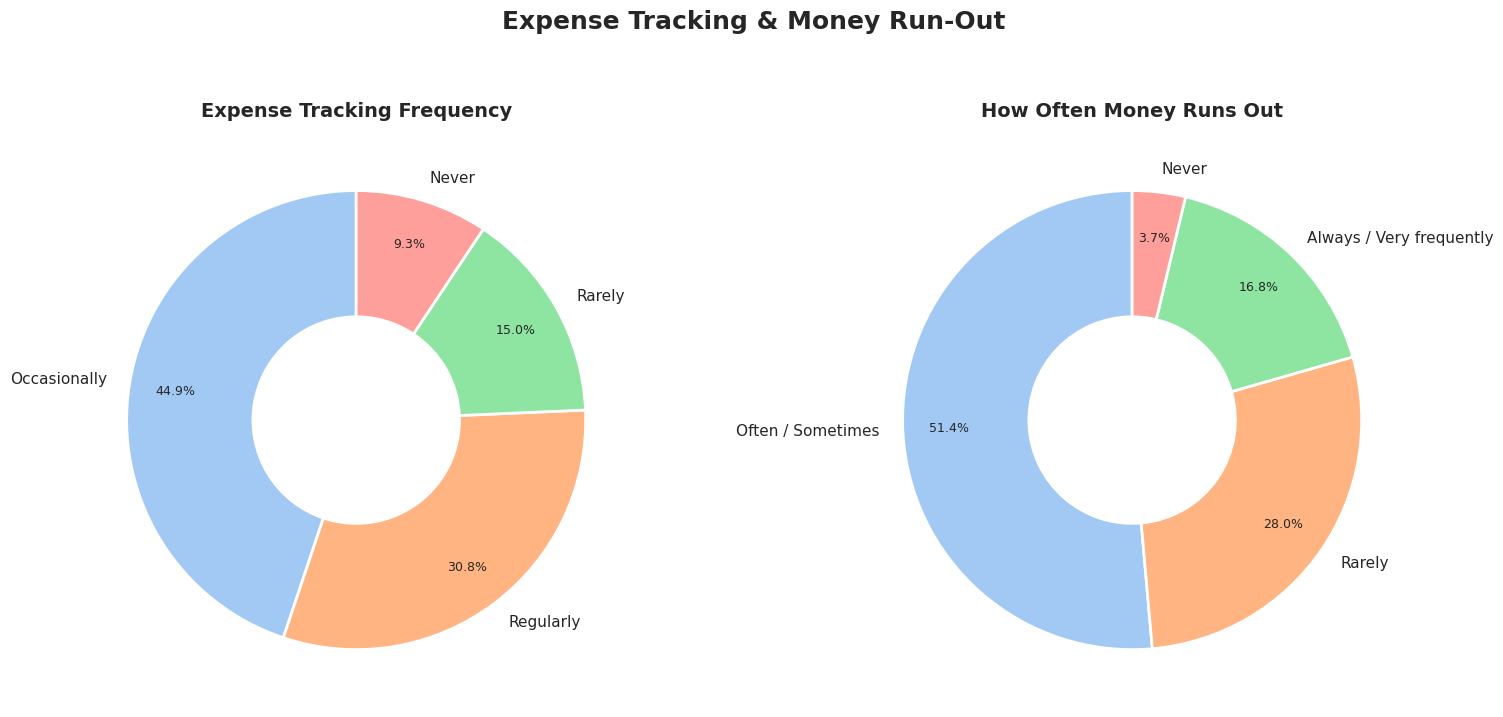

✅  Saved: 04_tracking_runout.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Expense Tracking & Money Run-Out', fontsize=18, fontweight='bold', y=1.02)

def donut(ax, col, title):
    vc = df[col].value_counts()
    wedges, texts, autotexts = ax.pie(
        vc.values, labels=vc.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel', len(vc)), startangle=90,
        pctdistance=0.80,
        wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2})
    for at in autotexts:
        at.set_fontsize(9)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)

donut(axes[0], 'Expense_Tracking_Freq', 'Expense Tracking Frequency')
donut(axes[1], 'Run_Out_Freq',          'How Often Money Runs Out')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(OUTPUT_DIR, '04_tracking_runout.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅  Saved: 04_tracking_runout.png')

## 8️⃣  Savings Behaviour

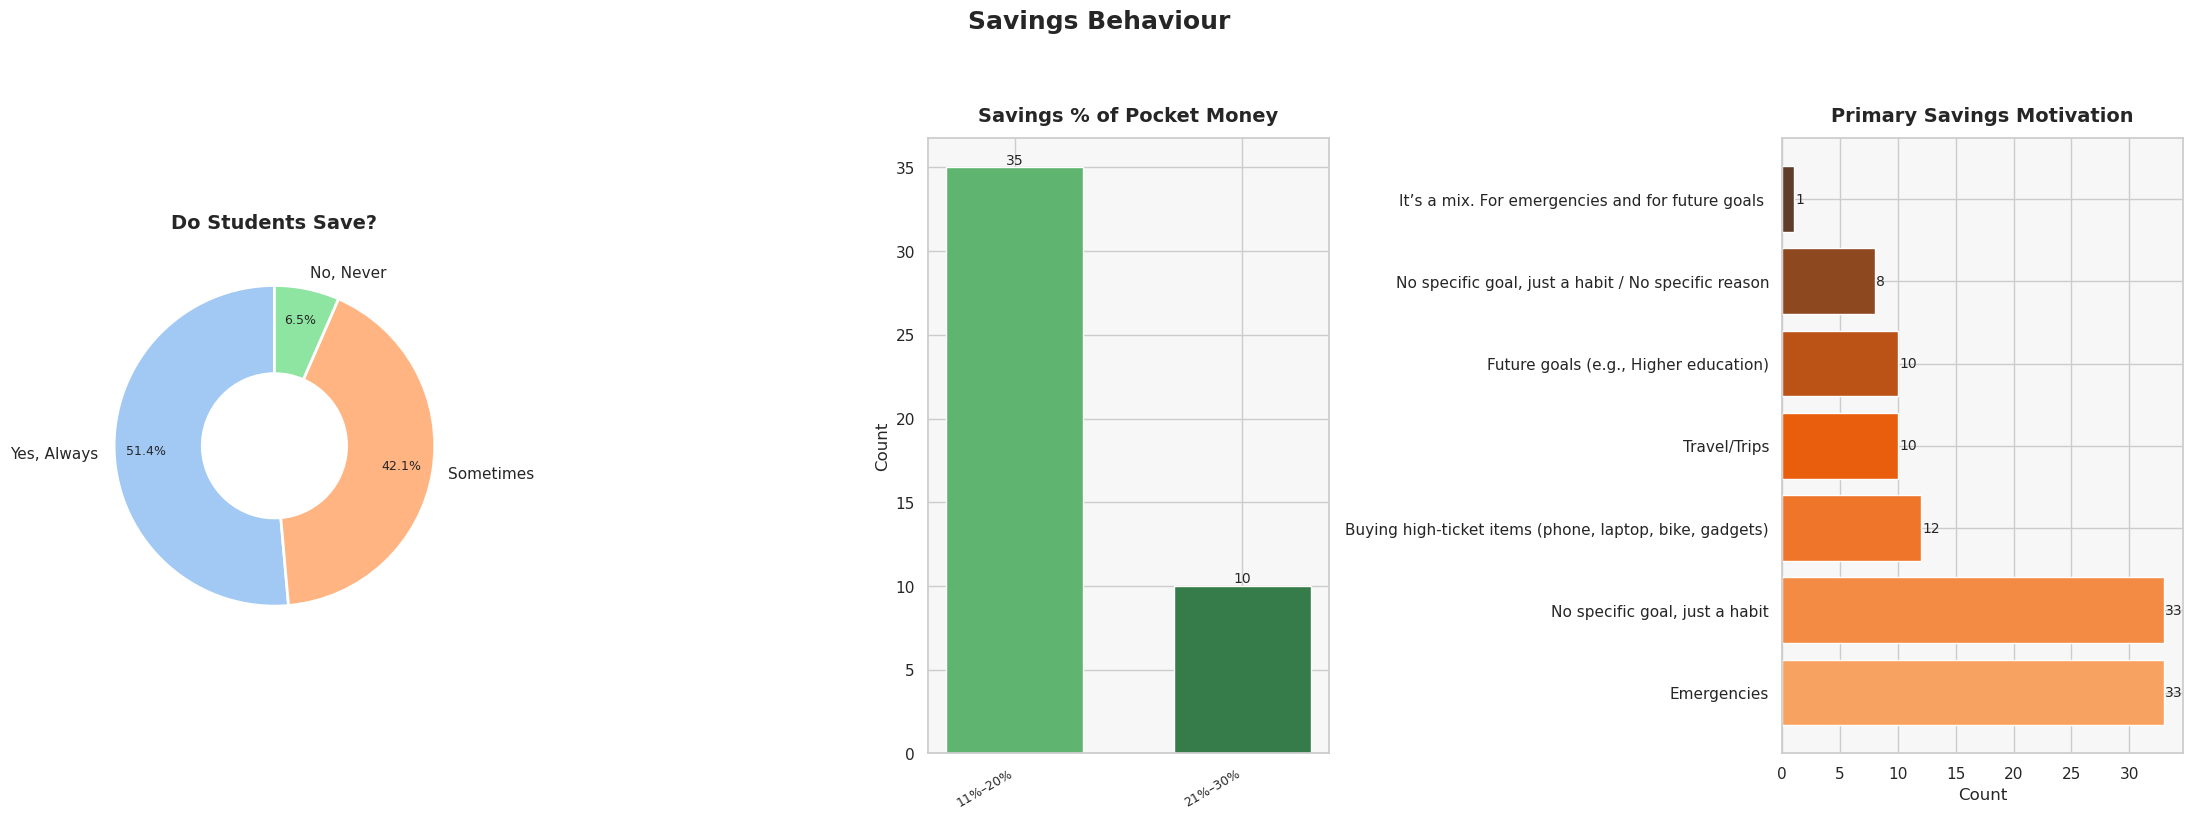

✅  Saved: 05_savings_behaviour.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('Savings Behaviour', fontsize=18, fontweight='bold', y=1.02)

# Do they save?
donut(axes[0], 'Saves_Money', 'Do Students Save?')

# Savings percentage
savings_order = ['Less than 10%','10%','11%\u201320%','21%\u201330%','31%\u201350%','More than 50%','I do not save']
sp = df['Savings_Percent'].value_counts().reindex(
    [s for s in savings_order if s in df['Savings_Percent'].unique()])
colors = sns.color_palette('Greens_d', len(sp))
axes[1].bar(range(len(sp)), sp.values, color=colors, edgecolor='white', width=0.6)
axes[1].set_xticks(range(len(sp)))
axes[1].set_xticklabels(sp.index, rotation=30, ha='right', fontsize=9)
axes[1].set_title('Savings % of Pocket Money', fontsize=14, fontweight='bold', pad=12)
axes[1].set_ylabel('Count')
for i, v in enumerate(sp.values):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontsize=10)

# Savings motivation
sm = df['Savings_Motivation'].value_counts()
axes[2].barh(sm.index, sm.values,
              color=sns.color_palette('Oranges_d', len(sm)), edgecolor='white')
axes[2].set_title('Primary Savings Motivation', fontsize=14, fontweight='bold', pad=12)
axes[2].set_xlabel('Count')
for i, v in enumerate(sm.values):
    axes[2].text(v + 0.1, i, str(v), va='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(OUTPUT_DIR, '05_savings_behaviour.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅  Saved: 05_savings_behaviour.png')

## 9️⃣  Influence Factors — Likert Analysis

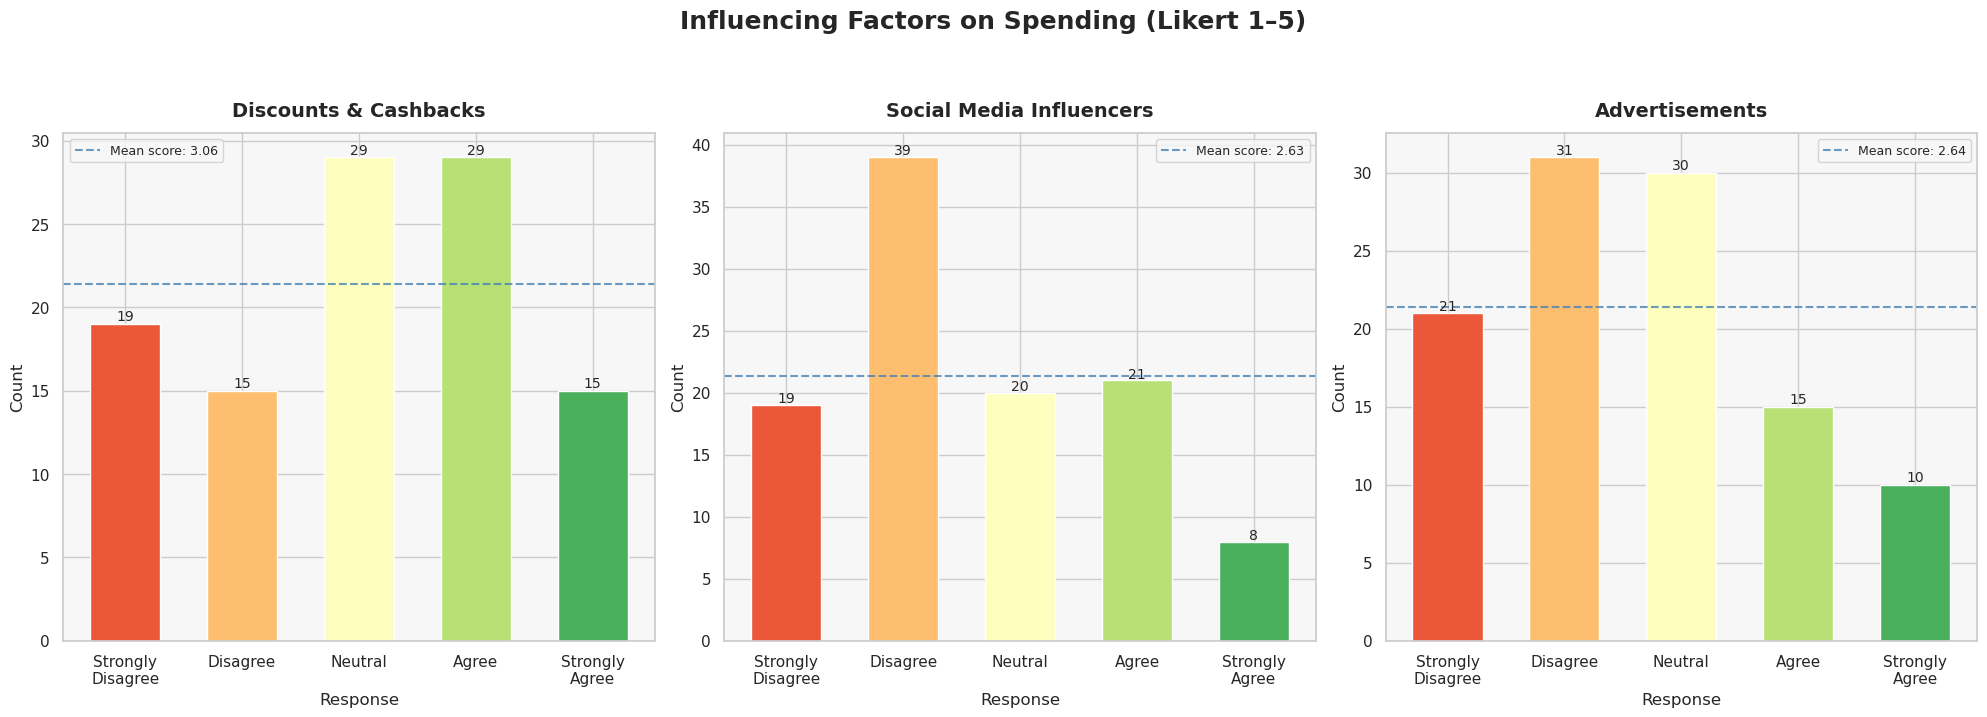

✅  Saved: 06_influence_factors.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Influencing Factors on Spending (Likert 1–5)', fontsize=18, fontweight='bold', y=1.02)

likert_map  = {1:'Strongly\nDisagree', 2:'Disagree', 3:'Neutral', 4:'Agree', 5:'Strongly\nAgree'}
likert_info = [
    ('Influence_Discounts',   'Discounts & Cashbacks'),
    ('Influence_SocialMedia', 'Social Media Influencers'),
    ('Influence_Ads',         'Advertisements'),
]

for ax, (col, title) in zip(axes, likert_info):
    vc = df[col].value_counts().sort_index()
    labels = [likert_map.get(k, str(k)) for k in vc.index]
    ax.bar(labels, vc.values,
           color=sns.color_palette('RdYlGn', len(vc)),
           edgecolor='white', width=0.6)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Response')
    ax.set_ylabel('Count')
    mean_val = df[col].mean()
    ax.axhline(vc.mean(), color='steelblue', linestyle='--', alpha=0.8,
               label=f'Mean score: {mean_val:.2f}')
    ax.legend(fontsize=9)
    for i, v in enumerate(vc.values):
        ax.text(i, v + 0.2, str(v), ha='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(OUTPUT_DIR, '06_influence_factors.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅  Saved: 06_influence_factors.png')

## 🔟  Financial Literacy

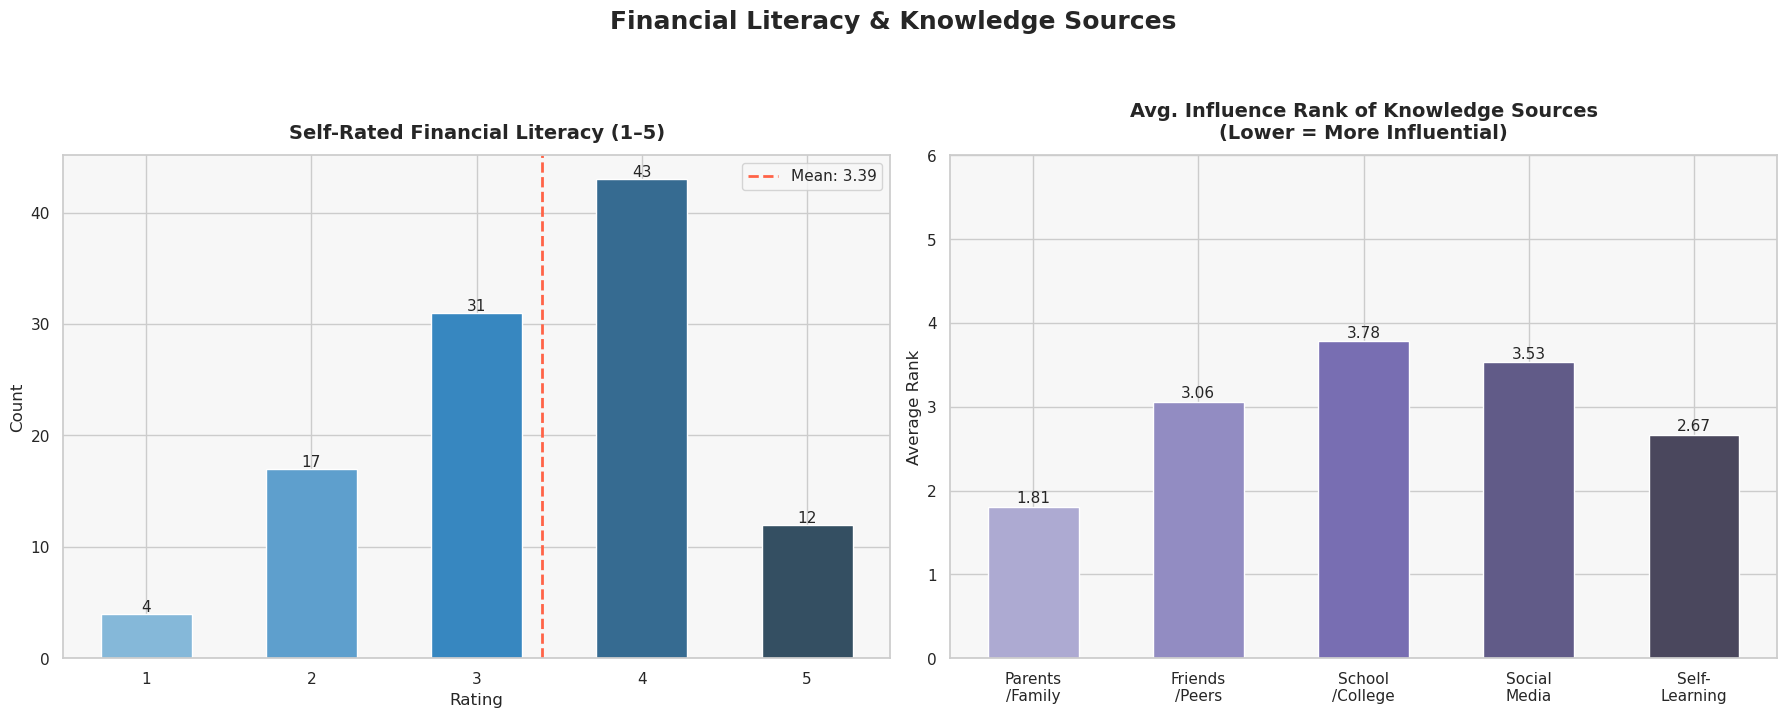

✅  Saved: 07_financial_literacy.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Financial Literacy & Knowledge Sources', fontsize=18, fontweight='bold', y=1.02)

fl = df['Financial_Literacy_Rating'].value_counts().sort_index()
axes[0].bar(fl.index, fl.values,
            color=sns.color_palette('Blues_d', len(fl)),
            edgecolor='white', width=0.55)
mean_fl = df['Financial_Literacy_Rating'].mean()
axes[0].axvline(mean_fl, color='tomato', linestyle='--', linewidth=2,
                label=f'Mean: {mean_fl:.2f}')
axes[0].set_title('Self-Rated Financial Literacy (1–5)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].legend()
for x, y in zip(fl.index, fl.values):
    axes[0].text(x, y + 0.2, str(y), ha='center', fontsize=11)

src_labels = ['Parents\n/Family','Friends\n/Peers','School\n/College','Social\nMedia','Self-\nLearning']
src_means  = [df[c].mean() for c in rank_cols]
bars = axes[1].bar(src_labels, src_means,
                   color=sns.color_palette('Purples_d', 5),
                   edgecolor='white', width=0.55)
axes[1].set_title('Avg. Influence Rank of Knowledge Sources\n(Lower = More Influential)',
                  fontsize=14, fontweight='bold', pad=12)
axes[1].set_ylabel('Average Rank')
axes[1].set_ylim(0, 6)
for bar, val in zip(bars, src_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(OUTPUT_DIR, '07_financial_literacy.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅  Saved: 07_financial_literacy.png')

## 1️⃣1️⃣  Peer Pressure & Budgeting Tools

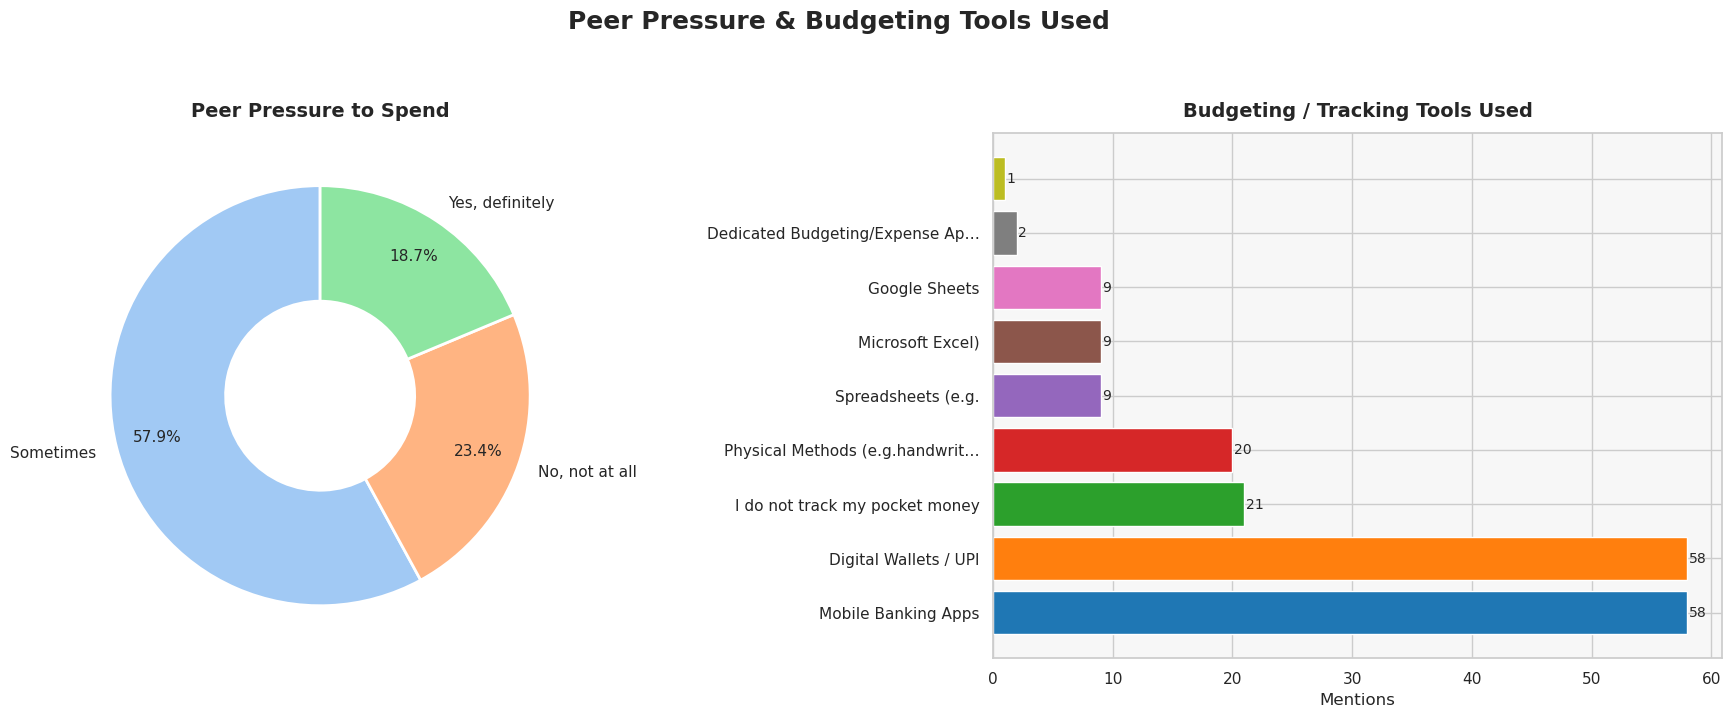

✅  Saved: 08_peer_pressure_tools.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Peer Pressure & Budgeting Tools Used', fontsize=18, fontweight='bold', y=1.02)

pp = df['Peer_Pressure'].value_counts()
axes[0].pie(pp.values, labels=pp.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel', len(pp)), startangle=90,
            pctdistance=0.80,
            wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Peer Pressure to Spend', fontsize=14, fontweight='bold', pad=12)

tool_flat = [t.strip()
             for sublist in df['Tracking_Tools'].dropna().str.split(', ')
             for t in sublist]
tc = pd.Series(tool_flat).value_counts()
short_tc = [t[:30] + '…' if len(t) > 30 else t for t in tc.index]
axes[1].barh(short_tc, tc.values,
              color=sns.color_palette('tab10', len(tc)), edgecolor='white')
axes[1].set_title('Budgeting / Tracking Tools Used', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Mentions')
for i, v in enumerate(tc.values):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(OUTPUT_DIR, '08_peer_pressure_tools.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅  Saved: 08_peer_pressure_tools.png')

## 1️⃣2️⃣  Correlation Heatmap

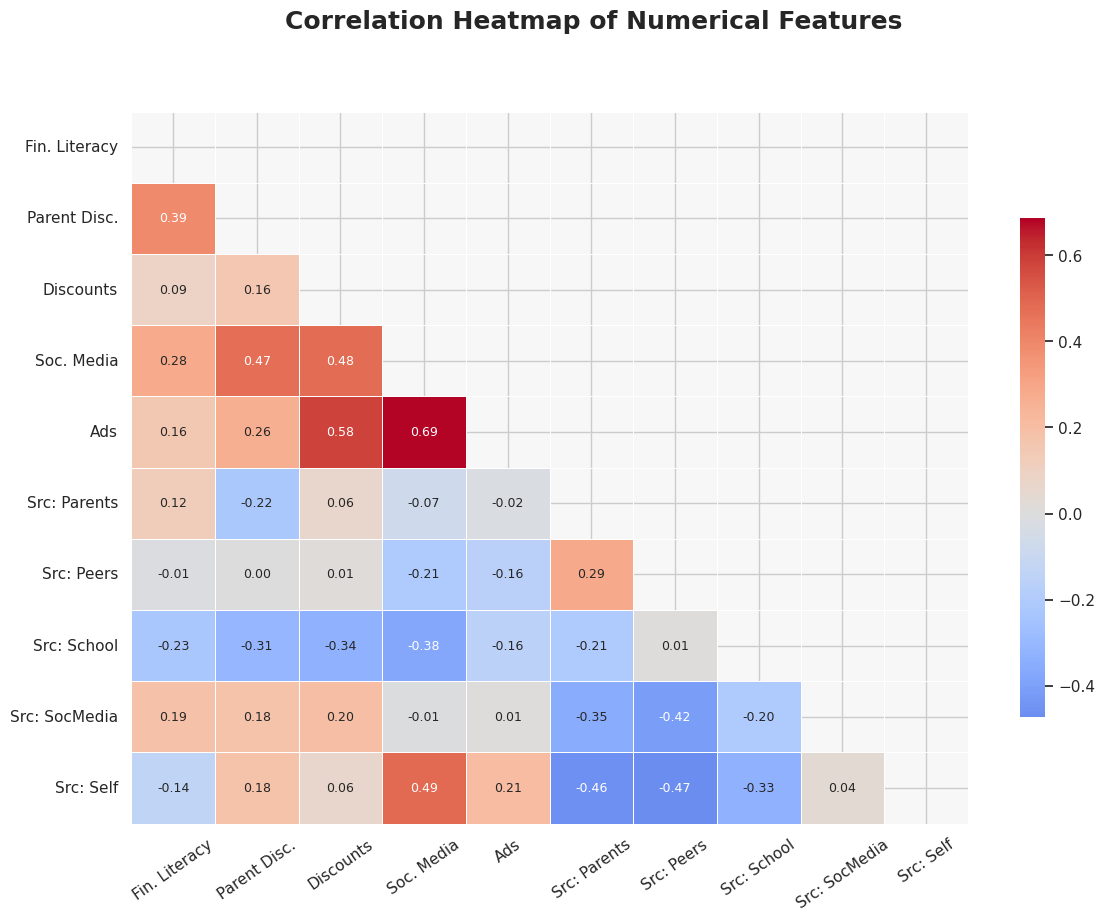

✅  Saved: 09_correlation_heatmap.png


In [12]:
num_df = df[['Financial_Literacy_Rating', 'Parent_Discussion_Freq',
             'Influence_Discounts', 'Influence_SocialMedia', 'Influence_Ads',
             'Source_Parents', 'Source_Peers', 'Source_School',
             'Source_SocialMedia', 'Source_SelfLearning']].dropna()

corr = num_df.corr()
nice_labels = ['Fin. Literacy', 'Parent Disc.', 'Discounts', 'Soc. Media', 'Ads',
               'Src: Parents', 'Src: Peers', 'Src: School', 'Src: SocMedia', 'Src: Self']

fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle('Correlation Heatmap of Numerical Features',
             fontsize=18, fontweight='bold', y=1.02)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white',
            xticklabels=nice_labels, yticklabels=nice_labels,
            annot_kws={'size': 9}, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(OUTPUT_DIR, '09_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅  Saved: 09_correlation_heatmap.png')

## 1️⃣3️⃣  Cross-Analysis: Savings vs Pocket Money & Run-Out

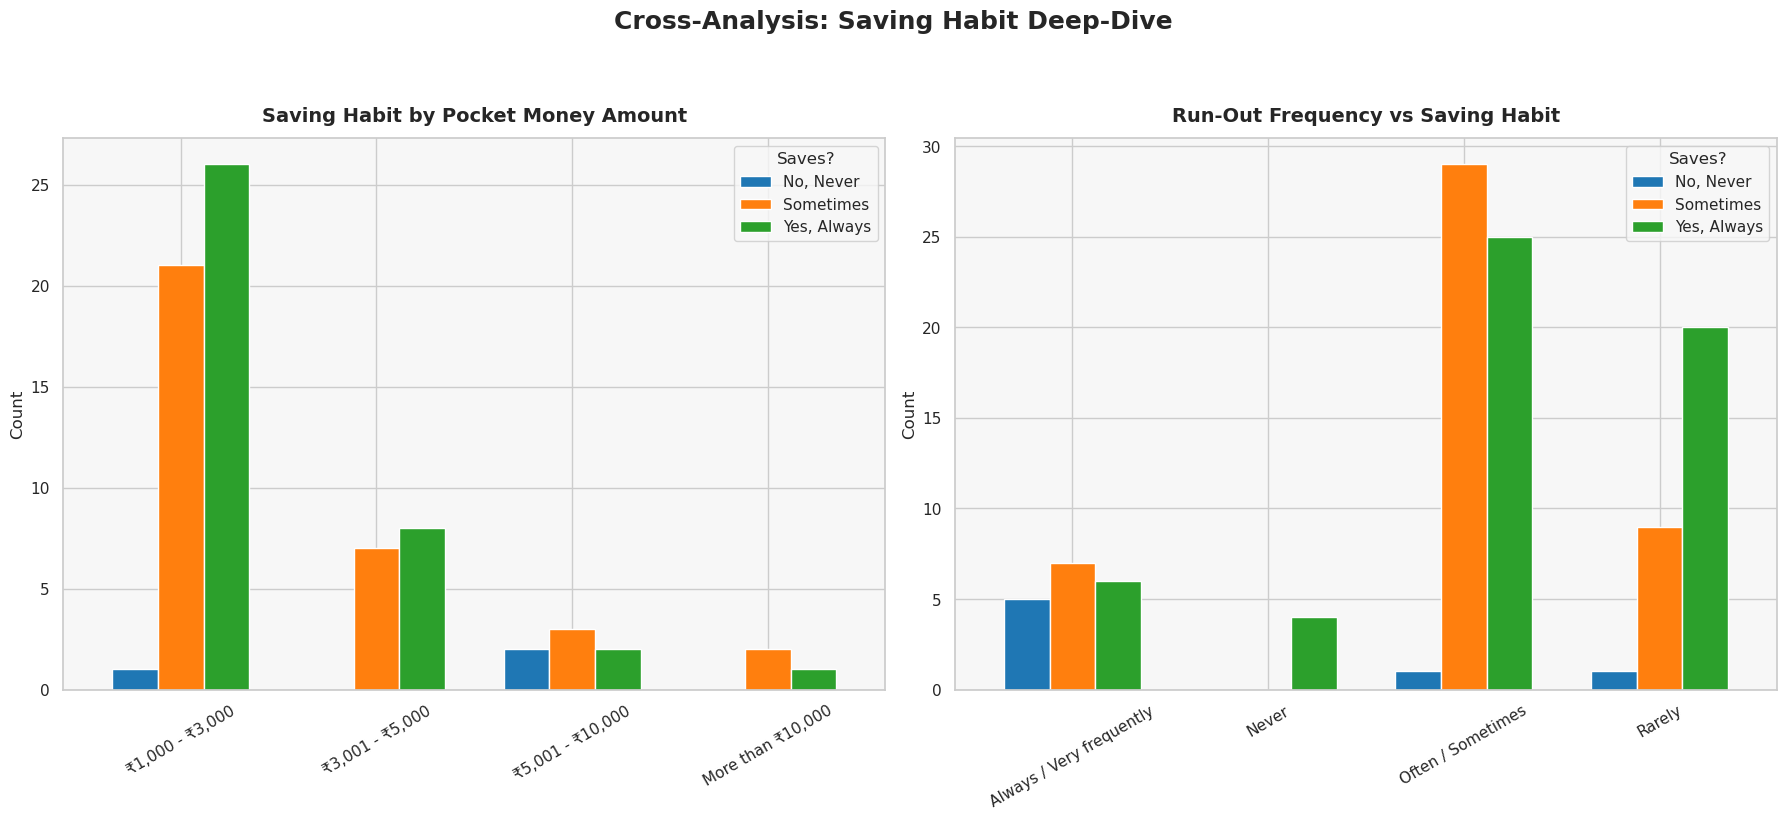

✅  Saved: 10_cross_analysis_savings.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Cross-Analysis: Saving Habit Deep-Dive', fontsize=18, fontweight='bold', y=1.02)

cross1 = pd.crosstab(df['Pocket_Money_Amount'], df['Saves_Money'])
cross1 = cross1.reindex([a for a in amount_order if a in cross1.index])
cross1.plot(kind='bar', ax=axes[0],
            color=sns.color_palette('tab10', cross1.shape[1]),
            edgecolor='white', width=0.7)
axes[0].set_title('Saving Habit by Pocket Money Amount', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Saves?')

cross2 = pd.crosstab(df['Run_Out_Freq'], df['Saves_Money'])
cross2.plot(kind='bar', ax=axes[1],
            color=sns.color_palette('tab10', cross2.shape[1]),
            edgecolor='white', width=0.7)
axes[1].set_title('Run-Out Frequency vs Saving Habit', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Saves?')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(OUTPUT_DIR, '10_cross_analysis_savings.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅  Saved: 10_cross_analysis_savings.png')

---
## 📊  FINAL DASHBOARD — Pocket Money Management Summary
---

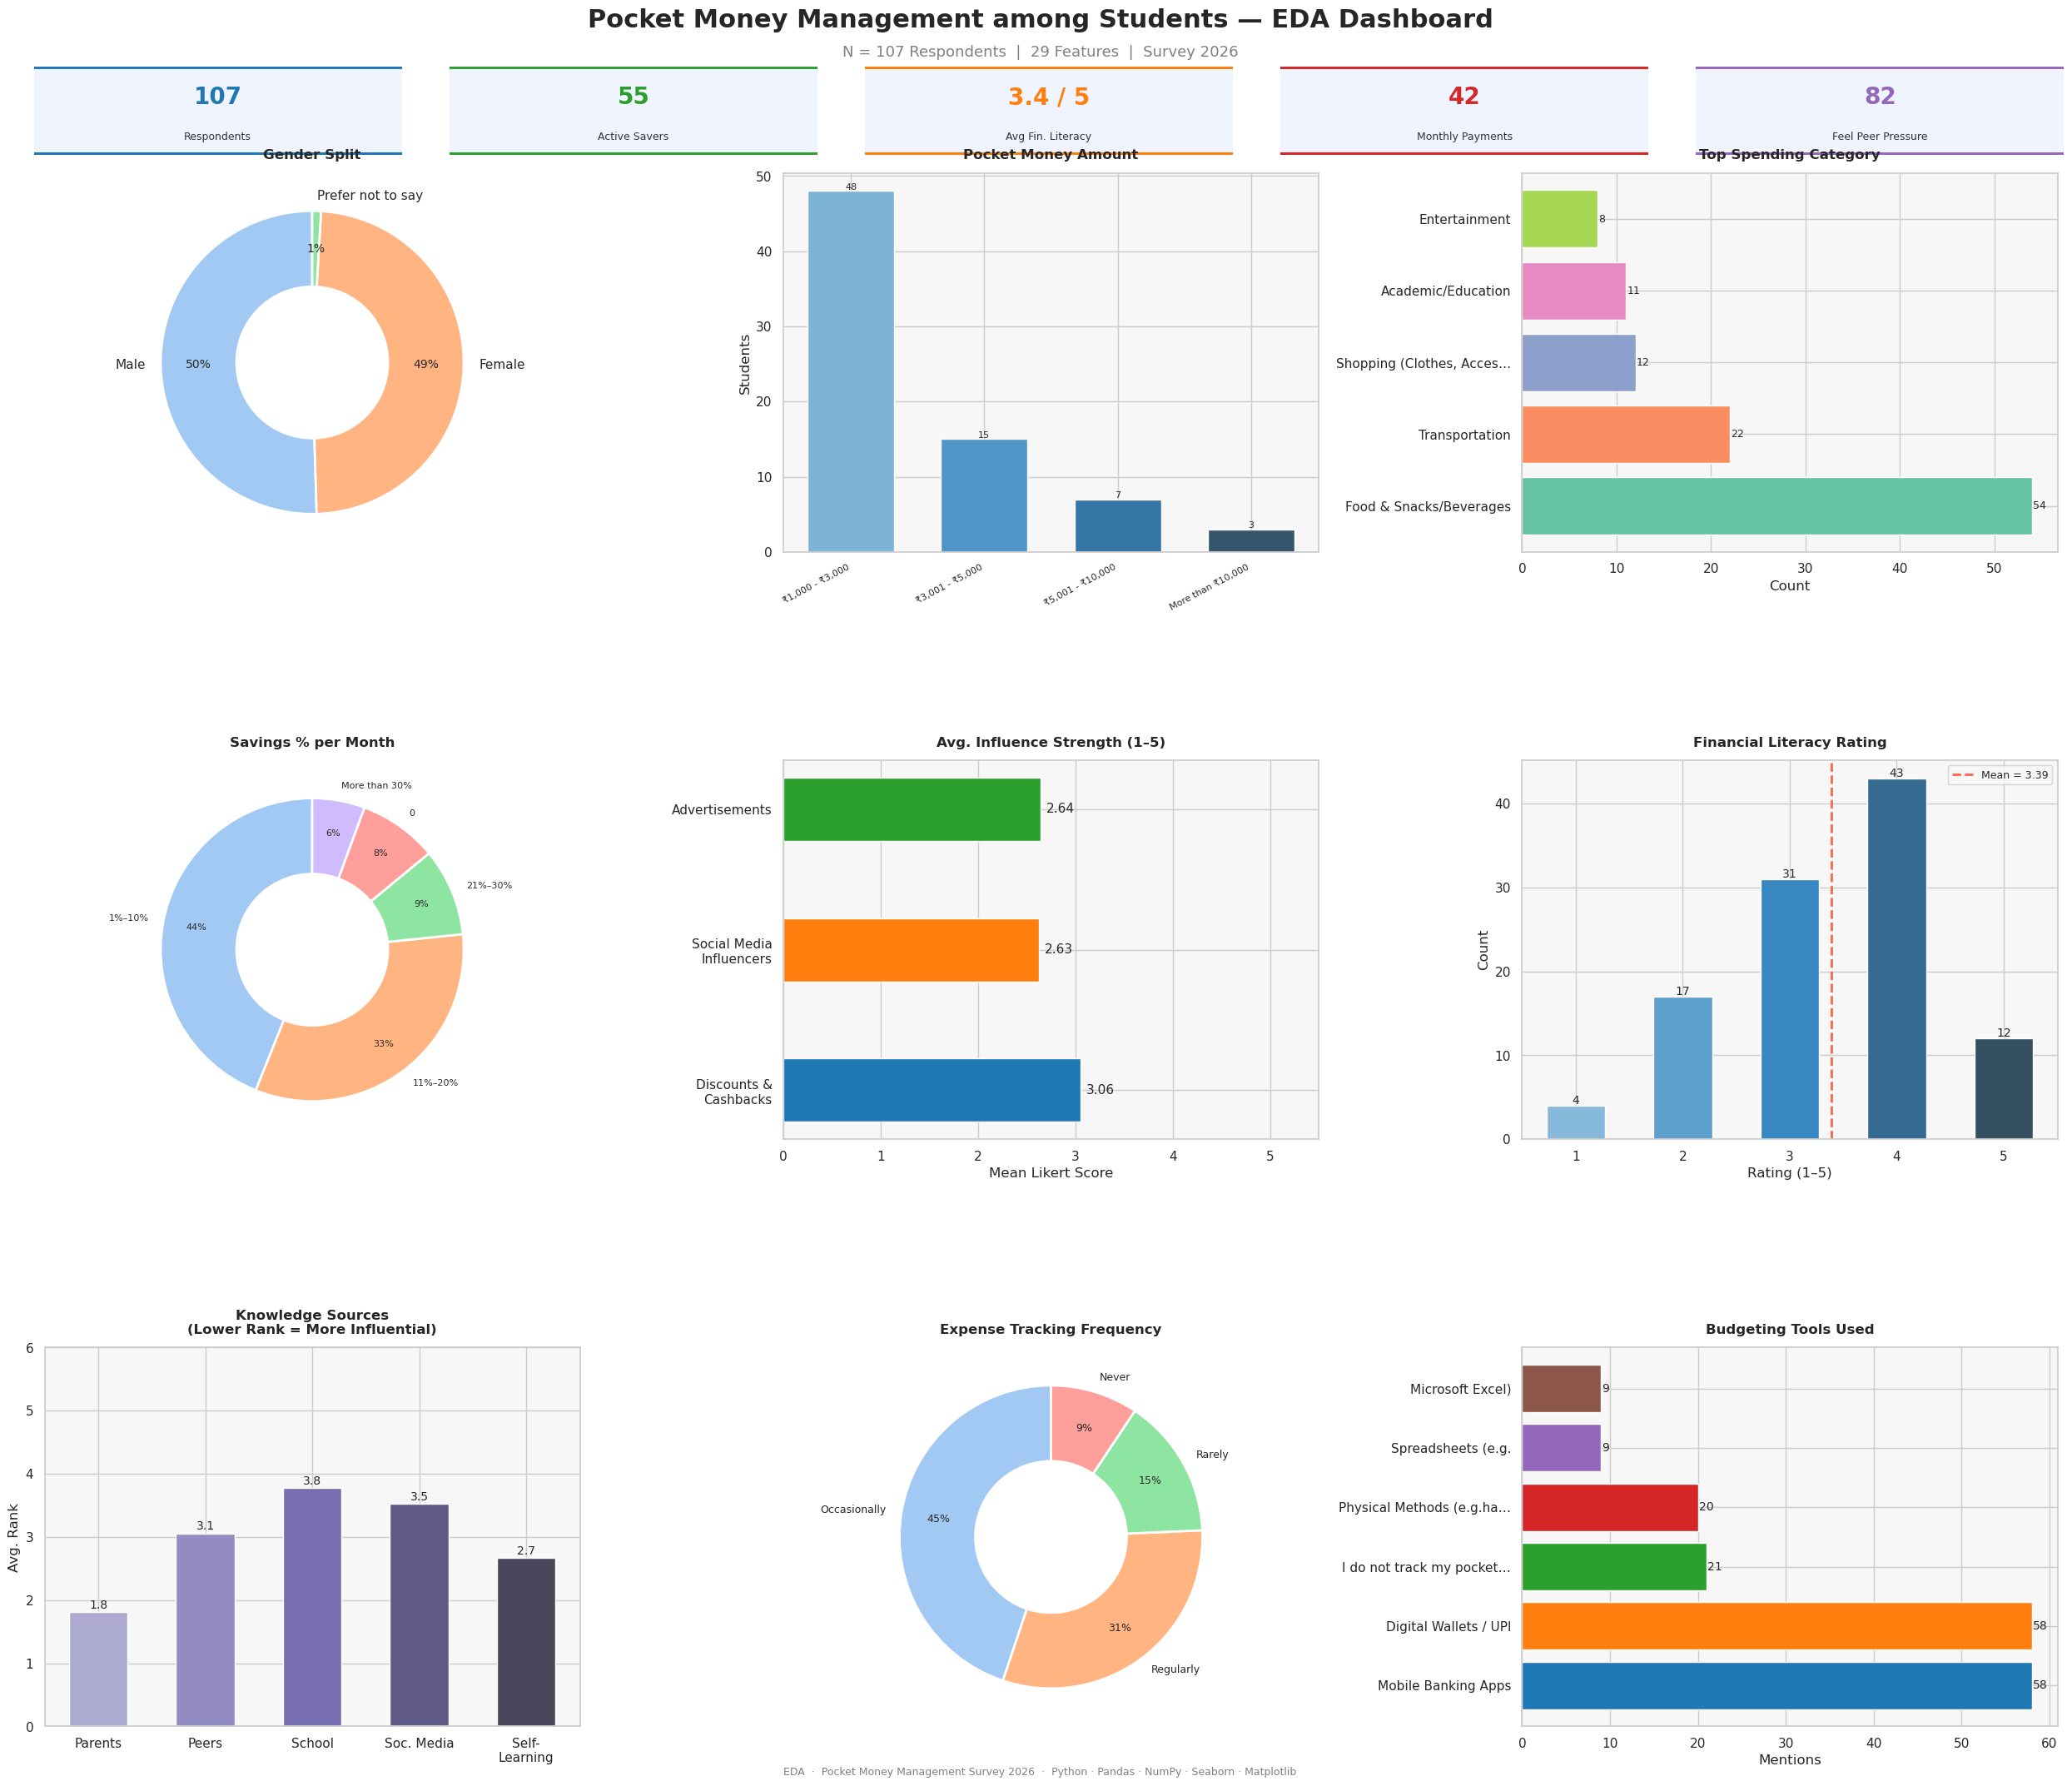

✅  Saved: 11_dashboard.png

🎉  All plots saved to: D:\lohith_prj\output_eda


In [14]:
# ════════════════════════════════════════════════════════════════
#   DASHBOARD  –  Pocket Money Management among Students
# ════════════════════════════════════════════════════════════════
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f7f7f7',
    'font.size':        10,
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.titlepad':    10,
})

TAB = sns.color_palette('tab10')
PAS = sns.color_palette('pastel')

fig = plt.figure(figsize=(26, 22), facecolor='white')

# ── Title banner ─────────────────────────────────────────────────
fig.text(0.5, 0.978,
         'Pocket Money Management among Students — EDA Dashboard',
         ha='center', va='top', fontsize=22, fontweight='bold')
fig.text(0.5, 0.958,
         f'N = {len(df)} Respondents  |  29 Features  |  Survey 2026',
         ha='center', va='top', fontsize=13, color='grey')

# ── KPI Cards ────────────────────────────────────────────────────
kpi_colors = [TAB[0], TAB[2], TAB[1], TAB[3], TAB[4]]
kpis = [
    ('Respondents',       str(len(df))),
    ('Active Savers',     str(df['Saves_Money'].str.contains('Yes', na=False).sum())),
    ('Avg Fin. Literacy', f"{df['Financial_Literacy_Rating'].mean():.1f} / 5"),
    ('Monthly Payments',  str((df['Pocket_Money_Frequency'] == 'Monthly').sum())),
    ('Feel Peer Pressure',str((df['Peer_Pressure'] != 'No, not at all').sum())),
]
for i, ((label, val), col) in enumerate(zip(kpis, kpi_colors)):
    ax_k = fig.add_axes([0.035 + i * 0.192, 0.898, 0.17, 0.048])
    ax_k.set_facecolor('#f0f4ff')
    ax_k.set_xlim(0, 1); ax_k.set_ylim(0, 1); ax_k.axis('off')
    ax_k.add_patch(mpatches.FancyBboxPatch(
        (0.01, 0.05), 0.98, 0.90,
        boxstyle='round,pad=0.04',
        facecolor='#f0f4ff', edgecolor=col, linewidth=2.5))
    ax_k.text(0.5, 0.65, val,   ha='center', va='center',
              fontsize=20, fontweight='bold', color=col)
    ax_k.text(0.5, 0.20, label, ha='center', va='center',
              fontsize=9, color='#333333')

# ── 3×3 grid ─────────────────────────────────────────────────────
gs = gridspec.GridSpec(3, 3, figure=fig,
                       left=0.04, right=0.97,
                       top=0.888, bottom=0.04,
                       hspace=0.55, wspace=0.38)

# [0,0] Gender donut
ax1 = fig.add_subplot(gs[0, 0])
gc2 = df['Gender'].value_counts()
ax1.pie(gc2.values, labels=gc2.index, autopct='%1.0f%%',
        colors=PAS[:len(gc2)], startangle=90, pctdistance=0.75,
        wedgeprops={'width': 0.50, 'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Gender Split', pad=12)

# [0,1] Pocket money amount
ax2 = fig.add_subplot(gs[0, 1])
amt2 = df['Pocket_Money_Amount'].value_counts().reindex(
    [a for a in amount_order if a in df['Pocket_Money_Amount'].unique()])
bars2 = ax2.bar(range(len(amt2)), amt2.values,
                color=sns.color_palette('Blues_d', len(amt2)),
                edgecolor='white', width=0.65)
ax2.set_xticks(range(len(amt2)))
ax2.set_xticklabels(amt2.index, rotation=28, ha='right', fontsize=8)
ax2.set_title('Pocket Money Amount', pad=12)
ax2.set_ylabel('Students')
for b in bars2:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2,
             str(int(b.get_height())), ha='center', fontsize=8)

# [0,2] Top spending category
ax3 = fig.add_subplot(gs[0, 2])
tsc3 = df['Top_Spend_Category'].value_counts()
sh_tsc = [t[:24] + '…' if len(t) > 24 else t for t in tsc3.index]
ax3.barh(sh_tsc, tsc3.values,
          color=sns.color_palette('Set2', len(tsc3)), edgecolor='white')
ax3.set_title('Top Spending Category', pad=12)
ax3.set_xlabel('Count')
for i, v in enumerate(tsc3.values):
    ax3.text(v + 0.1, i, str(v), va='center', fontsize=9)

# [1,0] Savings % donut
ax4 = fig.add_subplot(gs[1, 0])
sp3 = df['Savings_Percent'].value_counts()
sh_sp = [str(s)[:16] + '…' if len(str(s)) > 16 else str(s) for s in sp3.index]
ax4.pie(sp3.values, labels=sh_sp, autopct='%1.0f%%',
        colors=PAS[:len(sp3)], startangle=90, pctdistance=0.78,
        wedgeprops={'width': 0.50, 'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 8})
ax4.set_title('Savings % per Month', pad=12)

# [1,1] Influence means
ax5 = fig.add_subplot(gs[1, 1])
inf_means = {
    'Discounts &\nCashbacks'   : df['Influence_Discounts'].mean(),
    'Social Media\nInfluencers': df['Influence_SocialMedia'].mean(),
    'Advertisements'           : df['Influence_Ads'].mean(),
}
bars5 = ax5.barh(list(inf_means.keys()), list(inf_means.values()),
                  color=[TAB[0], TAB[1], TAB[2]], edgecolor='white', height=0.45)
ax5.set_xlim(0, 5.5)
ax5.set_title('Avg. Influence Strength (1–5)', pad=12)
ax5.set_xlabel('Mean Likert Score')
for b in bars5:
    ax5.text(b.get_width() + 0.06, b.get_y() + b.get_height()/2,
             f'{b.get_width():.2f}', va='center', fontsize=11)

# [1,2] Financial literacy
ax6 = fig.add_subplot(gs[1, 2])
fl3 = df['Financial_Literacy_Rating'].value_counts().sort_index()
ax6.bar(fl3.index, fl3.values,
         color=sns.color_palette('Blues_d', len(fl3)), edgecolor='white', width=0.55)
mfl = df['Financial_Literacy_Rating'].mean()
ax6.axvline(mfl, color='tomato', linestyle='--', linewidth=2, label=f'Mean = {mfl:.2f}')
ax6.set_title('Financial Literacy Rating', pad=12)
ax6.set_xlabel('Rating (1–5)')
ax6.set_ylabel('Count')
ax6.legend(fontsize=9)
for x, y in zip(fl3.index, fl3.values):
    ax6.text(x, y + 0.2, str(y), ha='center', fontsize=10)

# [2,0] Knowledge source avg rank
ax7 = fig.add_subplot(gs[2, 0])
src_n = ['Parents', 'Peers', 'School', 'Soc. Media', 'Self-\nLearning']
src_m = [df[c].mean() for c in rank_cols]
bars7 = ax7.bar(src_n, src_m,
                color=sns.color_palette('Purples_d', 5), edgecolor='white', width=0.55)
ax7.set_title('Knowledge Sources\n(Lower Rank = More Influential)', pad=12)
ax7.set_ylabel('Avg. Rank')
ax7.set_ylim(0, 6)
for b, v in zip(bars7, src_m):
    ax7.text(b.get_x() + b.get_width()/2, b.get_height() + 0.06,
             f'{v:.1f}', ha='center', fontsize=10)

# [2,1] Expense tracking donut
ax8 = fig.add_subplot(gs[2, 1])
etf2 = df['Expense_Tracking_Freq'].value_counts()
ax8.pie(etf2.values, labels=etf2.index, autopct='%1.0f%%',
        colors=PAS[:len(etf2)], startangle=90, pctdistance=0.75,
        wedgeprops={'width': 0.50, 'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 9})
ax8.set_title('Expense Tracking Frequency', pad=12)

# [2,2] Budgeting tools
ax9 = fig.add_subplot(gs[2, 2])
tool_flat2 = [t.strip()
              for sublist in df['Tracking_Tools'].dropna().str.split(', ')
              for t in sublist]
tc2 = pd.Series(tool_flat2).value_counts().head(6)
sh_tc2 = [t[:24] + '…' if len(t) > 24 else t for t in tc2.index]
ax9.barh(sh_tc2, tc2.values,
          color=sns.color_palette('tab10', len(tc2)), edgecolor='white')
ax9.set_title('Budgeting Tools Used', pad=12)
ax9.set_xlabel('Mentions')
for i, v in enumerate(tc2.values):
    ax9.text(v + 0.1, i, str(v), va='center', fontsize=10)

# ── Footer ────────────────────────────────────────────────────────
fig.text(0.5, 0.012,
         'EDA  ·  Pocket Money Management Survey 2026  ·  Python · Pandas · NumPy · Seaborn · Matplotlib',
         ha='center', va='bottom', fontsize=9, color='grey')

plt.savefig(os.path.join(OUTPUT_DIR, '11_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅  Saved: 11_dashboard.png')
print(f'\n🎉  All plots saved to: {os.path.abspath(OUTPUT_DIR)}')